**Ontología y Razonamiento Semántico (RDFLib y OWL-RL)**

In [28]:
!pip install rdflib
!pip install owlrl
!pip install rdflib

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


In [29]:
from rdflib import Graph, RDF, RDFS, Namespace, Literal, URIRef, XSD
from rdflib.namespace import FOAF, SKOS, DC
import owlrl


g = Graph()
NS = Namespace("http://unal.edu.co/cripto#")
g.bind("cripto", NS)
g.bind("foaf", FOAF)
g.bind("skos", SKOS)
g.bind("dc", DC)

#Se definen las clases y sus labels
clases = [
    (NS.AlgoritmoCriptografico, "Clase base que representa cualquier método de transformación de datos para seguridad."),
    (NS.CifradoSimetrico, "Algoritmos que utilizan una única clave para cifrar y descifrar la información."),
    (NS.CifradoAsimetrico, "Algoritmos que emplean un par de claves: una pública para cifrar y una privada para descifrar."),
    (NS.FuncionHash, "Algoritmos diseñados para generar una huella digital única de longitud fija a partir de datos."),
    (NS.ContextoUso, "Representa el entorno o escenario tecnológico donde se aplicará la solución criptográfica."),
    (NS.RecursoLimitado, "Entornos con restricciones severas de procesamiento, memoria o energía (ej. Sensores IoT)."),
    (NS.InfraestructuraCritica, "Sistemas de alta prioridad que requieren los estándares de seguridad más rigurosos."),
    (NS.EstadoSeguridad, "Categorización de la robustez y vigencia de un algoritmo frente a amenazas actuales."),
    (NS.AlgoritmoVulnerable, "Algoritmos que han sido deprecados o cuyas defensas han sido superadas teórica o prácticamente."),
    (NS.AlgoritmoPostCuantico, "Algoritmos diseñados para ser resistentes ante ataques realizados por computadoras cuánticas.")
]

#Se crean las clases con sus respectivos labels en el grafo
for clase, label in clases:
    g.add((clase, RDF.type, RDFS.Class))
    g.add((clase, RDFS.label, Literal(label, lang="es")))

#Se definen las jerarquias dentro del grafo
g.add((NS.CifradoSimetrico, RDFS.subClassOf, NS.AlgoritmoCriptografico))
g.add((NS.CifradoAsimetrico, RDFS.subClassOf, NS.AlgoritmoCriptografico))
g.add((NS.FuncionHash, RDFS.subClassOf, NS.AlgoritmoCriptografico))
g.add((NS.RecursoLimitado, RDFS.subClassOf, NS.ContextoUso))
g.add((NS.InfraestructuraCritica, RDFS.subClassOf, NS.ContextoUso))
g.add((NS.AlgoritmoVulnerable, RDFS.subClassOf, NS.EstadoSeguridad))
g.add((NS.AlgoritmoPostCuantico, RDFS.subClassOf, NS.EstadoSeguridad))

#Se definen las propiedades
propiedades_datos = [
    (NS.esRecomendadoPara, "Vincula un algoritmo con su contexto de uso ideal.", NS.AlgoritmoCriptografico, NS.ContextoUso),
    (NS.tieneNivelSeguridad, "Relaciona un algoritmo con su categoría de robustez.", NS.AlgoritmoCriptografico, NS.EstadoSeguridad),
    (NS.esVulnerableA, "Indica que un algoritmo tiene debilidades frente a una amenaza específica.", NS.AlgoritmoCriptografico, NS.EstadoSeguridad),
    (NS.utilizaClaveDeTamano, "Define la longitud de clave recomendada para el algoritmo.", NS.AlgoritmoCriptografico, XSD.integer),
    (NS.fueEstandarizadoPor, "Indica la organización que estandarizó el algoritmo (ej. NIST).", NS.AlgoritmoCriptografico, XSD.string),
    (NS.tieneVelocidadEjecucion, "Categoría cualitativa de rapidez (Alta, Media, Baja).", NS.AlgoritmoCriptografico, XSD.string),
    (NS.requiereMemoria, "Nivel de memoria RAM necesario para su ejecución.", NS.AlgoritmoCriptografico, XSD.string),
    (NS.añoDeCreacion, "Año en el que el algoritmo fue publicado originalmente.", NS.AlgoritmoCriptografico, XSD.gYear),
    (NS.tieneLimitacionGeneral, "Propiedad general para cualquier restricción del algoritmo.", NS.AlgoritmoCriptografico, RDFS.Literal),
    (NS.tieneLimitacionTecnica, "Limitación específica de implementación o hardware.", NS.AlgoritmoCriptografico, RDFS.Literal)
]

for prop, label, dominio, rango in propiedades_datos:
    g.add((prop, RDF.type, RDF.Property))
    g.add((prop, RDFS.label, Literal(label, lang="es")))
    g.add((prop, RDFS.domain, dominio))
    g.add((prop, RDFS.range, rango))

#Se implemeta la jerarquia de subpropiedades
g.add((NS.tieneLimitacionTecnica, RDFS.subPropertyOf, NS.tieneLimitacionGeneral))
g.add((NS.fueEstandarizadoPor, RDFS.subPropertyOf, FOAF.name))


# 1. Individuos de Cifrado Simétrico
# AES 256
g.add((NS.AES_256, RDF.type, NS.CifradoSimetrico))
g.add((NS.AES_256, RDFS.label, Literal("Estándar de Cifrado Avanzado de 256 bits", lang="es")))
g.add((NS.AES_256, NS.esRecomendadoPara, NS.BancaEnLinea))
g.add((NS.AES_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.AES_256, NS.esVulnerableA, Literal("Ataques de canal lateral si no se implementa bien", lang="es")))
g.add((NS.AES_256, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.AES_256, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.AES_256, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.AES_256, NS.requiereMemoria, Literal("Baja")))
g.add((NS.AES_256, NS.añoDeCreacion, Literal("1998", datatype=XSD.gYear)))
g.add((NS.AES_256, NS.tieneLimitacionGeneral, Literal("Requiere hardware que soporte instrucciones AES-NI para máxima velocidad", lang="es")))
g.add((NS.AES_256, NS.tieneLimitacionTecnica, Literal("Sensible a ataques de caché en implementaciones de software puras", lang="es")))

# DES (Deprecado pero es un ejemplo clásico)
g.add((NS.DES, RDF.type, NS.CifradoSimetrico))
g.add((NS.DES, RDFS.label, Literal("Estándar de Cifrado de Datos (Obsoleto)", lang="es")))
g.add((NS.DES, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.DES, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.DES, NS.esVulnerableA, Literal("Ataque de fuerza bruta por espacio de claves reducido", lang="es")))
g.add((NS.DES, NS.utilizaClaveDeTamano, Literal(56, datatype=XSD.integer)))
g.add((NS.DES, NS.fueEstandarizadoPor, Literal("NBS (ahora NIST)")))
g.add((NS.DES, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.DES, NS.requiereMemoria, Literal("Baja")))
g.add((NS.DES, NS.añoDeCreacion, Literal("1977", datatype=XSD.gYear)))
g.add((NS.DES, NS.tieneLimitacionGeneral, Literal("No debe usarse para proteger información sensible actual", lang="es")))
g.add((NS.DES, NS.tieneLimitacionTecnica, Literal("Clave demasiado corta para hardware moderno", lang="es")))

# Triple DES
g.add((NS.TDES, RDF.type, NS.CifradoSimetrico))
g.add((NS.TDES, RDFS.label, Literal("Triple DES - Aplicación triple del algoritmo DES", lang="es")))
g.add((NS.TDES, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.TDES, NS.tieneNivelSeguridad, NS.Obsoleto))
g.add((NS.TDES, NS.esVulnerableA, Literal("Ataque Meet-in-the-middle", lang="es")))
g.add((NS.TDES, NS.utilizaClaveDeTamano, Literal(168, datatype=XSD.integer)))
g.add((NS.TDES, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.TDES, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.TDES, NS.requiereMemoria, Literal("Baja")))
g.add((NS.TDES, NS.añoDeCreacion, Literal("1998", datatype=XSD.gYear)))
g.add((NS.TDES, NS.tieneLimitacionGeneral, Literal("Tres veces más lento que DES y menos eficiente que AES", lang="es")))
g.add((NS.TDES, NS.tieneLimitacionTecnica, Literal("Tamaño de bloque de 64 bits lo hace vulnerable a ataques de cumpleaños en grandes volúmenes de datos", lang="es")))

# ChaCha20 (Muy usado hoy en día por su velocidad)
g.add((NS.ChaCha20, RDF.type, NS.CifradoSimetrico))
g.add((NS.ChaCha20, RDFS.label, Literal("Cifrado de flujo de alta velocidad", lang="es")))
g.add((NS.ChaCha20, NS.esRecomendadoPara, NS.DispositivosMoviles))
g.add((NS.ChaCha20, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.ChaCha20, NS.esVulnerableA, Literal("Ataques de reutilización de nonce (si se usa incorrectamente)", lang="es")))
g.add((NS.ChaCha20, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.ChaCha20, NS.fueEstandarizadoPor, Literal("IETF")))
g.add((NS.ChaCha20, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.ChaCha20, NS.requiereMemoria, Literal("Baja")))
g.add((NS.ChaCha20, NS.añoDeCreacion, Literal("2008", datatype=XSD.gYear)))
g.add((NS.ChaCha20, NS.tieneLimitacionGeneral, Literal("Es un cifrado de flujo, requiere un manejo estricto del Nonce", lang="es")))
g.add((NS.ChaCha20, NS.tieneLimitacionTecnica, Literal("A diferencia de AES, no se beneficia de instrucciones como AES-NI, pero es más rápido en CPUs simples", lang="es")))


# 2. Individuos de Cifrado Asimétrico
# RSA 2048
g.add((NS.RSA_2048, RDF.type, NS.CifradoAsimetrico))
g.add((NS.RSA_2048, RDFS.label, Literal("RSA con clave de 2048 bits (Estándar actual)", lang="es")))
g.add((NS.RSA_2048, NS.esRecomendadoPara, NS.FirmaDigital))
g.add((NS.RSA_2048, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.RSA_2048, NS.esVulnerableA, Literal("Factorización de números primos por computación cuántica", lang="es")))
g.add((NS.RSA_2048, NS.utilizaClaveDeTamano, Literal(2048, datatype=XSD.integer)))
g.add((NS.RSA_2048, NS.fueEstandarizadoPor, Literal("RSA Laboratories / IETF")))
g.add((NS.RSA_2048, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.RSA_2048, NS.requiereMemoria, Literal("Media")))
g.add((NS.RSA_2048, NS.añoDeCreacion, Literal("1977", datatype=XSD.gYear)))
g.add((NS.RSA_2048, NS.tieneLimitacionGeneral, Literal("Mucho más lento que el cifrado simétrico; se usa solo para pequeñas cantidades de datos", lang="es")))
g.add((NS.RSA_2048, NS.tieneLimitacionTecnica, Literal("Requiere claves muy grandes para mantener el nivel de seguridad frente a ataques de factorización", lang="es")))

# RSA 4096 (Más seguro, más lento)
g.add((NS.RSA_4096, RDF.type, NS.CifradoAsimetrico))
g.add((NS.RSA_4096, RDFS.label, Literal("RSA con clave de 4096 bits (Alta seguridad)", lang="es")))
g.add((NS.RSA_4096, NS.esRecomendadoPara, NS.AlmacenamientoLargoPlazo))
g.add((NS.RSA_4096, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.RSA_4096, NS.esVulnerableA, Literal("Algoritmo de Shor en computadoras cuánticas de gran escala", lang="es")))
g.add((NS.RSA_4096, NS.utilizaClaveDeTamano, Literal(4096, datatype=XSD.integer)))
g.add((NS.RSA_4096, NS.fueEstandarizadoPor, Literal("NIST / BSI")))
g.add((NS.RSA_4096, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.RSA_4096, NS.requiereMemoria, Literal("Alta")))
g.add((NS.RSA_4096, NS.añoDeCreacion, Literal("2002", datatype=XSD.gYear)))
g.add((NS.RSA_4096, NS.tieneLimitacionGeneral, Literal("Generar claves de este tamaño puede tardar varios segundos en CPUs lentas", lang="es")))
g.add((NS.RSA_4096, NS.tieneLimitacionTecnica, Literal("El proceso de descifrado es significativamente más lento que en RSA 2048", lang="es")))

# ECC 256 (Curva Elíptica)
g.add((NS.ECC_256, RDF.type, NS.CifradoAsimetrico))
g.add((NS.ECC_256, RDFS.label, Literal("Criptografía de Curva Elíptica de 256 bits", lang="es")))
g.add((NS.ECC_256, NS.esRecomendadoPara, NS.Blockchain))
g.add((NS.ECC_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.ECC_256, NS.esVulnerableA, Literal("Ataques de canal lateral en implementaciones mal protegidas", lang="es")))
g.add((NS.ECC_256, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.ECC_256, NS.fueEstandarizadoPor, Literal("NIST / SECG")))
g.add((NS.ECC_256, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.ECC_256, NS.requiereMemoria, Literal("Baja")))
g.add((NS.ECC_256, NS.añoDeCreacion, Literal("1985", datatype=XSD.gYear)))
g.add((NS.ECC_256, NS.tieneLimitacionGeneral, Literal("Más difícil de implementar correctamente que RSA", lang="es")))
g.add((NS.ECC_256, NS.tieneLimitacionTecnica, Literal("La seguridad depende totalmente de la curva elegida (ej. secp256k1)", lang="es")))

# Diffie-Hellman (Intercambio de claves)
g.add((NS.DiffieHellman, RDF.type, NS.CifradoAsimetrico))
g.add((NS.DiffieHellman, RDFS.label, Literal("Protocolo de intercambio de claves", lang="es")))
g.add((NS.DiffieHellman, NS.esRecomendadoPara, NS.TransmisionTiempoReal))
g.add((NS.DiffieHellman, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.DiffieHellman, NS.esVulnerableA, Literal("Ataques de Hombre en el Medio (MitM) si no se usa con firmas digitales", lang="es")))
g.add((NS.DiffieHellman, NS.utilizaClaveDeTamano, Literal(2048, datatype=XSD.integer)))
g.add((NS.DiffieHellman, NS.fueEstandarizadoPor, Literal("IETF (RFC 2631)")))
g.add((NS.DiffieHellman, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.DiffieHellman, NS.requiereMemoria, Literal("Media")))
g.add((NS.DiffieHellman, NS.añoDeCreacion, Literal("1976", datatype=XSD.gYear)))
g.add((NS.DiffieHellman, NS.tieneLimitacionGeneral, Literal("Solo sirve para acordar una clave, no para cifrar mensajes directamente", lang="es")))
g.add((NS.DiffieHellman, NS.tieneLimitacionTecnica, Literal("No proporciona autenticación por sí mismo; ambas partes deben confiar en que el otro es quien dice ser", lang="es")))

# 3. Individuos de Función Hash
g.add ((NS.SHA_256, RDF.type, NS.FuncionHash))
g.add((NS.SHA_256, NS.esRecomendadoPara, NS.AutenticacionUsuarios))
g.add((NS.SHA_256, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SHA_256, NS.esVulnerableA, Literal("Ataques de extensión de longitud (en ciertos modos)", lang="es")))
g.add((NS.SHA_256, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer))) # Tamaño del digest
g.add((NS.SHA_256, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.SHA_256, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.SHA_256, NS.requiereMemoria, Literal("Baja")))
g.add((NS.SHA_256, NS.añoDeCreacion, Literal("2001", datatype=XSD.gYear)))
g.add((NS.SHA_256, NS.tieneLimitacionGeneral, Literal("Ampliamente compatible pero vulnerable a ataques cuánticos a largo plazo", lang="es")))
g.add((NS.SHA_256, NS.tieneLimitacionTecnica, Literal("Diseño basado en Merkle-Damgård", lang="es")))

# 2. SHA-1 (Vulnerable y Obsoleto)
g.add((NS.SHA_1, RDF.type, NS.FuncionHash))
g.add((NS.SHA_1, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.SHA_1, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.SHA_1, NS.esVulnerableA, Literal("Ataques de colisión prácticos", lang="es")))
g.add((NS.SHA_1, NS.utilizaClaveDeTamano, Literal(160, datatype=XSD.integer)))
g.add((NS.SHA_1, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.SHA_1, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.SHA_1, NS.requiereMemoria, Literal("Baja")))
g.add((NS.SHA_1, NS.añoDeCreacion, Literal("1995", datatype=XSD.gYear)))
g.add((NS.SHA_1, NS.tieneLimitacionGeneral, Literal("Ya no se considera seguro para firmas digitales", lang="es")))
g.add((NS.SHA_1, NS.tieneLimitacionTecnica, Literal("Google demostró la primera colisión en 2017", lang="es")))

# 3. MD5 (El más rápido pero el más inseguro)
g.add((NS.MD5, RDF.type, NS.FuncionHash))
g.add((NS.MD5, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.MD5, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.MD5, NS.esVulnerableA, Literal("Colisiones casi instantáneas", lang="es")))
g.add((NS.MD5, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.MD5, NS.fueEstandarizadoPor, Literal("IETF")))
g.add((NS.MD5, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.MD5, NS.requiereMemoria, Literal("Baja")))
g.add((NS.MD5, NS.añoDeCreacion, Literal("1991", datatype=XSD.gYear)))
g.add((NS.MD5, NS.tieneLimitacionGeneral, Literal("Solo útil para verificar integridad de archivos no críticos (checksums)", lang="es")))
g.add((NS.MD5, NS.tieneLimitacionTecnica, Literal("Criptográficamente roto; fácil de falsificar", lang="es")))

# 4. SHA-3 (Keccak - El futuro)
g.add((NS.SHA_3, RDF.type, NS.FuncionHash))
g.add((NS.SHA_3, NS.esRecomendadoPara, NS.Blockchain))
g.add((NS.SHA_3, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SHA_3, NS.esVulnerableA, Literal("Resistente a la mayoría de ataques conocidos de SHA-2", lang="es")))
g.add((NS.SHA_3, NS.utilizaClaveDeTamano, Literal(512, datatype=XSD.integer)))
g.add((NS.SHA_3, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.SHA_3, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.SHA_3, NS.requiereMemoria, Literal("Media")))
g.add((NS.SHA_3, NS.añoDeCreacion, Literal("2015", datatype=XSD.gYear)))
g.add((NS.SHA_3, NS.tieneLimitacionGeneral, Literal("Estructura de esponja, muy diferente a SHA-2", lang="es")))
g.add((NS.SHA_3, NS.tieneLimitacionTecnica, Literal("Más lento en hardware estándar que SHA-2 pero más seguro", lang="es")))

# 4 individuos para RecursoLimitado

# Sensor de Temperatura IoT (Extremadamente limitado)
g.add((NS.SensorIoT_Temp, RDF.type, NS.RecursoLimitado))
g.add((NS.SensorIoT_Temp, RDFS.label, Literal("Sensor IoT de baja potencia", lang="es")))
g.add((NS.SensorIoT_Temp, NS.esRecomendadoPara, NS.ChaCha20)) # Recomendamos un algoritmo ligero
g.add((NS.SensorIoT_Temp, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SensorIoT_Temp, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.SensorIoT_Temp, NS.requiereMemoria, Literal("Baja")))
g.add((NS.SensorIoT_Temp, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.SensorIoT_Temp, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.SensorIoT_Temp, NS.tieneLimitacionTecnica, Literal("Batería de moneda (CR2032), CPU de 8 bits")))
g.add((NS.SensorIoT_Temp, NS.tieneLimitacionGeneral, Literal("No soporta cifrado asimétrico pesado como RSA")))

#Tarjeta Inteligente (SmartCard / NFC)
g.add((NS.SmartCard_NFC, RDF.type, NS.RecursoLimitado))
g.add((NS.SmartCard_NFC, RDFS.label, Literal("Tarjeta de pago sin contacto", lang="es")))
g.add((NS.SmartCard_NFC, NS.esRecomendadoPara, NS.ECC_256)) # Curva elíptica por ser compacta
g.add((NS.SmartCard_NFC, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.SmartCard_NFC, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.SmartCard_NFC, NS.requiereMemoria, Literal("Baja")))
g.add((NS.SmartCard_NFC, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.SmartCard_NFC, NS.añoDeCreacion, Literal("2023", datatype=XSD.gYear)))
g.add((NS.SmartCard_NFC, NS.tieneLimitacionTecnica, Literal("Espacio de almacenamiento EEPROM muy reducido")))
g.add((NS.SmartCard_NFC, NS.tieneLimitacionGeneral, Literal("Vulnerable a ataques de canal lateral si no hay protección física")))

# Marcapasos Médico (IoT Médico Crítico)
g.add((NS.Marcapasos_Conectado, RDF.type, NS.RecursoLimitado))
g.add((NS.Marcapasos_Conectado, RDFS.label, Literal("Dispositivo médico implantable", lang="es")))
g.add((NS.Marcapasos_Conectado, NS.esRecomendadoPara, NS.AES_128))
g.add((NS.Marcapasos_Conectado, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Marcapasos_Conectado, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.Marcapasos_Conectado, NS.requiereMemoria, Literal("Baja")))
g.add((NS.Marcapasos_Conectado, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.Marcapasos_Conectado, NS.añoDeCreacion, Literal("2025", datatype=XSD.gYear)))
g.add((NS.Marcapasos_Conectado, NS.tieneLimitacionTecnica, Literal("Ciclos de CPU limitados para evitar sobrecalentamiento")))
g.add((NS.Marcapasos_Conectado, NS.tieneLimitacionGeneral, Literal("La vida de la batería es crítica para la vida del paciente")))

# Router Doméstico Antiguo (Legacy Resource Limited)
g.add((NS.Router_Legacy, RDF.type, NS.RecursoLimitado))
g.add((NS.Router_Legacy, RDFS.label, Literal("Router de casa modelo 2010", lang="es")))
g.add((NS.Router_Legacy, NS.esRecomendadoPara, NS.TDES))
g.add((NS.Router_Legacy, NS.tieneNivelSeguridad, NS.Obsoleto))
g.add((NS.Router_Legacy, NS.utilizaClaveDeTamano, Literal(168, datatype=XSD.integer)))
g.add((NS.Router_Legacy, NS.requiereMemoria, Literal("Baja")))
g.add((NS.Router_Legacy, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.Router_Legacy, NS.añoDeCreacion, Literal("2010", datatype=XSD.gYear)))
g.add((NS.Router_Legacy, NS.tieneLimitacionTecnica, Literal("Memoria RAM de 16MB, procesador MIPS antiguo")))
g.add((NS.Router_Legacy, NS.tieneLimitacionGeneral, Literal("No soporta protocolos modernos como TLS 1.3")))

# 6 individuos para InfraestructuraCritica

# Central Eléctrica Inteligente (Smart Grid)
g.add((NS.Central_Electrica, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Central_Electrica, RDFS.label, Literal("Sistema de control de red eléctrica nacional", lang="es")))
g.add((NS.Central_Electrica, NS.esRecomendadoPara, NS.AES_256)) # Cifrado robusto para comandos SCADA
g.add((NS.Central_Electrica, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Central_Electrica, NS.utilizaClaveDeTamano, Literal(256, datatype=XSD.integer)))
g.add((NS.Central_Electrica, NS.fueEstandarizadoPor, Literal("NIST SP 800-82")))
g.add((NS.Central_Electrica, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.Central_Electrica, NS.añoDeCreacion, Literal("2022", datatype=XSD.gYear)))
g.add((NS.Central_Electrica, NS.tieneLimitacionTecnica, Literal("Requiere latencia menor a 10ms para control en tiempo real")))
g.add((NS.Central_Electrica, NS.tieneLimitacionGeneral, Literal("Sujeto a regulaciones de seguridad nacional (NERC CIP)")))

# Planta de Tratamiento de Agua (SCADA System)
g.add((NS.Planta_Agua, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Planta_Agua, RDFS.label, Literal("Control de potabilización y distribución de agua", lang="es")))
g.add((NS.Planta_Agua, NS.esRecomendadoPara, NS.RSA_4096)) # Para firmas de integridad de firmware
g.add((NS.Planta_Agua, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Planta_Agua, NS.utilizaClaveDeTamano, Literal(4096, datatype=XSD.integer)))
g.add((NS.Planta_Agua, NS.requiereMemoria, Literal("Alta")))
g.add((NS.Planta_Agua, NS.tieneVelocidadEjecucion, Literal("Baja")))
g.add((NS.Planta_Agua, NS.añoDeCreacion, Literal("2021", datatype=XSD.gYear)))
g.add((NS.Planta_Agua, NS.tieneLimitacionTecnica, Literal("Hardware industrial con ciclos de vida de 20 años")))
g.add((NS.Planta_Agua, NS.tieneLimitacionGeneral, Literal("Dificultad para actualizar algoritmos in-situ")))

# Satélite de Comunicaciones Gubernamental
g.add((NS.Satelite_Gob, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Satelite_Gob, RDFS.label, Literal("Enlace satelital de datos oficiales", lang="es")))
g.add((NS.Satelite_Gob, NS.esRecomendadoPara, NS.Kyber)) # Post-cuántico para evitar 'Harvest Now, Decrypt Later'
g.add((NS.Satelite_Gob, NS.tieneNivelSeguridad, NS.AlgoritmoPostCuantico))
g.add((NS.Satelite_Gob, NS.utilizaClaveDeTamano, Literal(768, datatype=XSD.integer)))
g.add((NS.Satelite_Gob, NS.fueEstandarizadoPor, Literal("NIST PQC Project")))
g.add((NS.Satelite_Gob, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.Satelite_Gob, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Satelite_Gob, NS.tieneLimitacionTecnica, Literal("Sensible a la radiación cósmica; requiere redundancia en memoria")))
g.add((NS.Satelite_Gob, NS.tieneLimitacionGeneral, Literal("Imposible de intervenir físicamente tras el lanzamiento")))

# Red de Control de Tráfico Ferroviario (ERTMS)
g.add((NS.Control_Ferroviario, RDF.type, NS.InfraestructuraCritica))
g.add((NS.Control_Ferroviario, RDFS.label, Literal("Gestión de señalización de trenes de alta velocidad", lang="es")))
g.add((NS.Control_Ferroviario, NS.esRecomendadoPara, NS.SHA_3)) # Integridad de mensajes de vía
g.add((NS.Control_Ferroviario, NS.tieneNivelSeguridad, NS.AltaSeguridad))
g.add((NS.Control_Ferroviario, NS.utilizaClaveDeTamano, Literal(512, datatype=XSD.integer)))
g.add((NS.Control_Ferroviario, NS.requiereMemoria, Literal("Media")))
g.add((NS.Control_Ferroviario, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.Control_Ferroviario, NS.añoDeCreacion, Literal("2023", datatype=XSD.gYear)))
g.add((NS.Control_Ferroviario, NS.tieneLimitacionTecnica, Literal("Protocolos propietarios que deben coexistir con estándares abiertos")))
g.add((NS.Control_Ferroviario, NS.tieneLimitacionGeneral, Literal("Fallo en integridad puede causar colisiones fatales")))


#  6 individuos para AlgoritmoVulnerable

# Colision_MD5_Práctica (Escenario de colisión de hash)
g.add((NS.Colision_MD5, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.Colision_MD5, NS.esRecomendadoPara, NS.ECC_256))
g.add((NS.Colision_MD5, RDFS.label, Literal("Colisión de Hash en MD5 detectada", lang="es")))
g.add((NS.Colision_MD5, NS.esVulnerableA, Literal("Ataques de preimagen y colisiones", lang="es")))
g.add((NS.Colision_MD5, NS.tieneNivelSeguridad, NS.Obsoleto))
g.add((NS.Colision_MD5, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.Colision_MD5, NS.fueEstandarizadoPor, Literal("Hans Dobbertin / Arjen Lenstra")))
g.add((NS.Colision_MD5, NS.tieneVelocidadEjecucion, Literal("Alta"))) # Sigue siendo rápido, pero inútil
g.add((NS.Colision_MD5, NS.añoDeCreacion, Literal("2004", datatype=XSD.gYear))) # Año de la primera colisión práctica
g.add((NS.Colision_MD5, NS.tieneLimitacionTecnica, Literal("Permite generar dos archivos distintos con el mismo hash")))
g.add((NS.Colision_MD5, NS.tieneLimitacionGeneral, Literal("No usar para firmas digitales o almacenamiento de contraseñas")))

# Debilidad_RC4_Keystream (Cifrado de flujo roto)
g.add((NS.Debilidad_RC4, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.Debilidad_RC4, RDFS.label, Literal("Sesgo en el flujo de claves RC4", lang="es")))
g.add((NS.Debilidad_RC4, NS.esRecomendadoPara, NS.SistemasHeredados))
g.add((NS.Debilidad_RC4, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.Debilidad_RC4, NS.esVulnerableA, Literal("Ataques estadísticos Fluhrer-Mantin-Shamir (FMS)", lang="es")))
g.add((NS.Debilidad_RC4, NS.utilizaClaveDeTamano, Literal(128, datatype=XSD.integer)))
g.add((NS.Debilidad_RC4, NS.requiereMemoria, Literal("Baja")))
g.add((NS.Debilidad_RC4, NS.añoDeCreacion, Literal("2015", datatype=XSD.gYear))) # Año de prohibición oficial en TLS
g.add((NS.Debilidad_RC4, NS.tieneLimitacionTecnica, Literal("Los primeros bytes del keystream no son aleatorios")))
g.add((NS.Debilidad_RC4, NS.tieneLimitacionGeneral, Literal("Prohibido por el RFC 7465 para todas las versiones de TLS")))

# Factorizacion_RSA_1024 (Clave corta asimétrica)
g.add((NS.Factorizacion_RSA_1024, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.Factorizacion_RSA_1024, NS.esRecomendadoPara, NS.ECC_))
g.add((NS.Factorizacion_RSA_1024, RDFS.label, Literal("RSA-1024 Factorizable por supercomputación", lang="es")))
g.add((NS.Factorizacion_RSA_1024, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.Factorizacion_RSA_1024, NS.esVulnerableA, Literal("Factorización de enteros de gran escala", lang="es")))
g.add((NS.Factorizacion_RSA_1024, NS.utilizaClaveDeTamano, Literal(1024, datatype=XSD.integer)))
g.add((NS.Factorizacion_RSA_1024, NS.fueEstandarizadoPor, Literal("NIST (Deprecado desde 2010)")))
g.add((NS.Factorizacion_RSA_1024, NS.tieneVelocidadEjecucion, Literal("Media")))
g.add((NS.Factorizacion_RSA_1024, NS.añoDeCreacion, Literal("2010", datatype=XSD.gYear)))
g.add((NS.Factorizacion_RSA_1024, NS.tieneLimitacionTecnica, Literal("Poder de cómputo actual permite romper estas claves en meses")))
g.add((NS.Factorizacion_RSA_1024, NS.tieneLimitacionGeneral, Literal("Ya no cumple con los estándares de cumplimiento PCI-DSS")))

# FuerzaBruta_DES_56 (Espacio de búsqueda pequeño)
g.add((NS.FuerzaBruta_DES, RDF.type, NS.AlgoritmoVulnerable))
g.add((NS.FuerzaBruta_DES, NS.esRecomendadoPara, NS.AutenticacionUsuarios))
g.add((NS.FuerzaBruta_DES, RDFS.label, Literal("DES-56 vulnerable a cracking masivo", lang="es")))
g.add((NS.FuerzaBruta_DES, NS.tieneNivelSeguridad, NS.AlgoritmoVulnerable))
g.add((NS.FuerzaBruta_DES, NS.esVulnerableA, Literal("Ataque de fuerza bruta por claves de 56 bits", lang="es")))
g.add((NS.FuerzaBruta_DES, NS.utilizaClaveDeTamano, Literal(56, datatype=XSD.integer)))
g.add((NS.FuerzaBruta_DES, NS.requiereMemoria, Literal("Baja")))
g.add((NS.FuerzaBruta_DES, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.FuerzaBruta_DES, NS.añoDeCreacion, Literal("1999", datatype=XSD.gYear))) # Año del desafío DES III roto en 22h
g.add((NS.FuerzaBruta_DES, NS.tieneLimitacionTecnica, Literal("Hardware especializado (ASIC) puede probar todas las claves en minutos")))
g.add((NS.FuerzaBruta_DES, NS.tieneLimitacionGeneral, Literal("Completamente inseguro para cualquier propósito moderno")))

# 7 indiviudos para AlgoritmoPostCuantico

# RYSTALS-Kyber (Mecanismo de Encapsulación de Claves - KEM)
g.add((NS.Kyber, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Kyber, RDFS.label, Literal("Kyber - Estándar NIST para intercambio de claves cuántico", lang="es")))
g.add((NS.Kyber, NS.esRecomendadoPara, NS.InfraestructuraCritica))
g.add((NS.Kyber, NS.tieneNivelSeguridad, NS.AlgoritmoPostCuantico))
g.add((NS.Kyber, NS.esVulnerableA, Literal("Ataques de canal lateral en implementaciones físicas", lang="es")))
g.add((NS.Kyber, NS.utilizaClaveDeTamano, Literal(1632, datatype=XSD.integer))) # Tamaño de clave pública en bytes para Kyber-768
g.add((NS.Kyber, NS.fueEstandarizadoPor, Literal("NIST (FIPS 203)")))
g.add((NS.Kyber, NS.tieneVelocidadEjecucion, Literal("Alta"))) # Muy rápido en comparación con RSA
g.add((NS.Kyber, NS.requiereMemoria, Literal("Media")))
g.add((NS.Kyber, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear))) # Año de estandarización final
g.add((NS.Kyber, NS.tieneLimitacionTecnica, Literal("Basado en el problema de 'Learning with Errors' (LWE) en redes (lattices)")))
g.add((NS.Kyber, NS.tieneLimitacionGeneral, Literal("Sustituto directo de Diffie-Hellman y RSA para el futuro")))

# CRYSTALS-Dilithium (Firma Digital PQC)
g.add((NS.Dilithium, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Dilithium, RDFS.label, Literal("Dilithium - Firma digital basada en redes", lang="es")))
g.add((NS.Dilithium, NS.esRecomendadoPara, NS.FirmaDigital))
g.add((NS.Dilithium, NS.tieneNivelSeguridad, NS.AlgoritmoPostCuantico))
g.add((NS.Dilithium, NS.esVulnerableA, Literal("No vulnerable a ataques cuánticos conocidos", lang="es")))
g.add((NS.Dilithium, NS.utilizaClaveDeTamano, Literal(2592, datatype=XSD.integer)))
g.add((NS.Dilithium, NS.fueEstandarizadoPor, Literal("NIST (FIPS 204)")))
g.add((NS.Dilithium, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.Dilithium, NS.requiereMemoria, Literal("Media")))
g.add((NS.Dilithium, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Dilithium, NS.tieneLimitacionTecnica, Literal("Firmas significativamente más grandes que las de ECDSA o RSA")))
g.add((NS.Dilithium, NS.tieneLimitacionGeneral, Literal("Equilibrio óptimo entre tamaño de firma y velocidad de verificación")))

# SPHINCS+ (Firma basada en Hash)
g.add((NS.SphincsPlus, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.SphincsPlus, RDFS.label, Literal("SPHINCS+ - Firma digital 'stateless' basada en hash", lang="es")))
g.add((NS.SphincsPlus, NS.esRecomendadoPara, NS.AlmacenamientoLargoPlazo))
g.add((NS.SphincsPlus, NS.tieneNivelSeguridad, NS.AlgoritmoPostCuantico))
g.add((NS.SphincsPlus, NS.esVulnerableA, Literal("Resistente incluso si los problemas de redes son resueltos", lang="es")))
g.add((NS.SphincsPlus, NS.utilizaClaveDeTamano, Literal(32, datatype=XSD.integer))) # Tamaño de semilla
g.add((NS.SphincsPlus, NS.fueEstandarizadoPor, Literal("NIST (FIPS 205)")))
g.add((NS.SphincsPlus, NS.tieneVelocidadEjecucion, Literal("Baja"))) # Es mucho más lento que Dilithium
g.add((NS.SphincsPlus, NS.requiereMemoria, Literal("Alta")))
g.add((NS.SphincsPlus, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.SphincsPlus, NS.tieneLimitacionTecnica, Literal("Generación de firma muy costosa computacionalmente")))
g.add((NS.SphincsPlus, NS.tieneLimitacionGeneral, Literal("Considerado el más seguro a largo plazo por basarse solo en funciones hash")))

# FALCON (Firma compacta basada en redes)
g.add((NS.Falcon, RDF.type, NS.AlgoritmoPostCuantico))
g.add((NS.Falcon, RDFS.label, Literal("Falcon - Firma digital de alta eficiencia", lang="es")))
g.add((NS.Falcon, NS.esRecomendadoPara, NS.DispositivosIoT))
g.add((NS.Falcon, NS.tieneNivelSeguridad, NS.AlgoritmoPostCuantico))
g.add((NS.Falcon, NS.esVulnerableA, Literal("Complejidad de implementación de punto flotante", lang="es")))
g.add((NS.Falcon, NS.utilizaClaveDeTamano, Literal(897, datatype=XSD.integer)))
g.add((NS.Falcon, NS.fueEstandarizadoPor, Literal("NIST")))
g.add((NS.Falcon, NS.tieneVelocidadEjecucion, Literal("Alta")))
g.add((NS.Falcon, NS.requiereMemoria, Literal("Baja"))) # Es el más ligero para dispositivos pequeños
g.add((NS.Falcon, NS.añoDeCreacion, Literal("2024", datatype=XSD.gYear)))
g.add((NS.Falcon, NS.tieneLimitacionTecnica, Literal("Requiere aritmética de punto flotante de alta precisión, difícil en algunos chips")))
g.add((NS.Falcon, NS.tieneLimitacionGeneral, Literal("El mejor para cuando el ancho de banda es el recurso más limitado")))


# --- GUARDAR Y VERIFICAR ---
# Esto guarda todo tu trabajo en un archivo real
g.serialize(destination="cripto_ontologia.ttl", format="turtle")
print("Ontología exportada exitosamente a 'cripto_ontologia.ttl'")


print(g.serialize(format="turtle"))

Ontología exportada exitosamente a 'cripto_ontologia.ttl'
@prefix cripto: <http://unal.edu.co/cripto#> .
@prefix foaf: <http://xmlns.com/foaf/0.1/> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

cripto:AlgoritmoCriptografico a rdfs:Class ;
    rdfs:label "Clase base que representa cualquier método de transformación de datos para seguridad."@es .

cripto:AlgoritmoPostCuantico a rdfs:Class ;
    rdfs:label "Algoritmos diseñados para ser resistentes ante ataques realizados por computadoras cuánticas."@es ;
    rdfs:subClassOf cripto:EstadoSeguridad .

cripto:AlgoritmoVulnerable a rdfs:Class ;
    rdfs:label "Algoritmos que han sido deprecados o cuyas defensas han sido superadas teórica o prácticamente."@es ;
    rdfs:subClassOf cripto:EstadoSeguridad .

cripto:CifradoAsimetrico a rdfs:Class ;
    rdfs:label "Algoritmos que emplean un par de claves: una pública para c

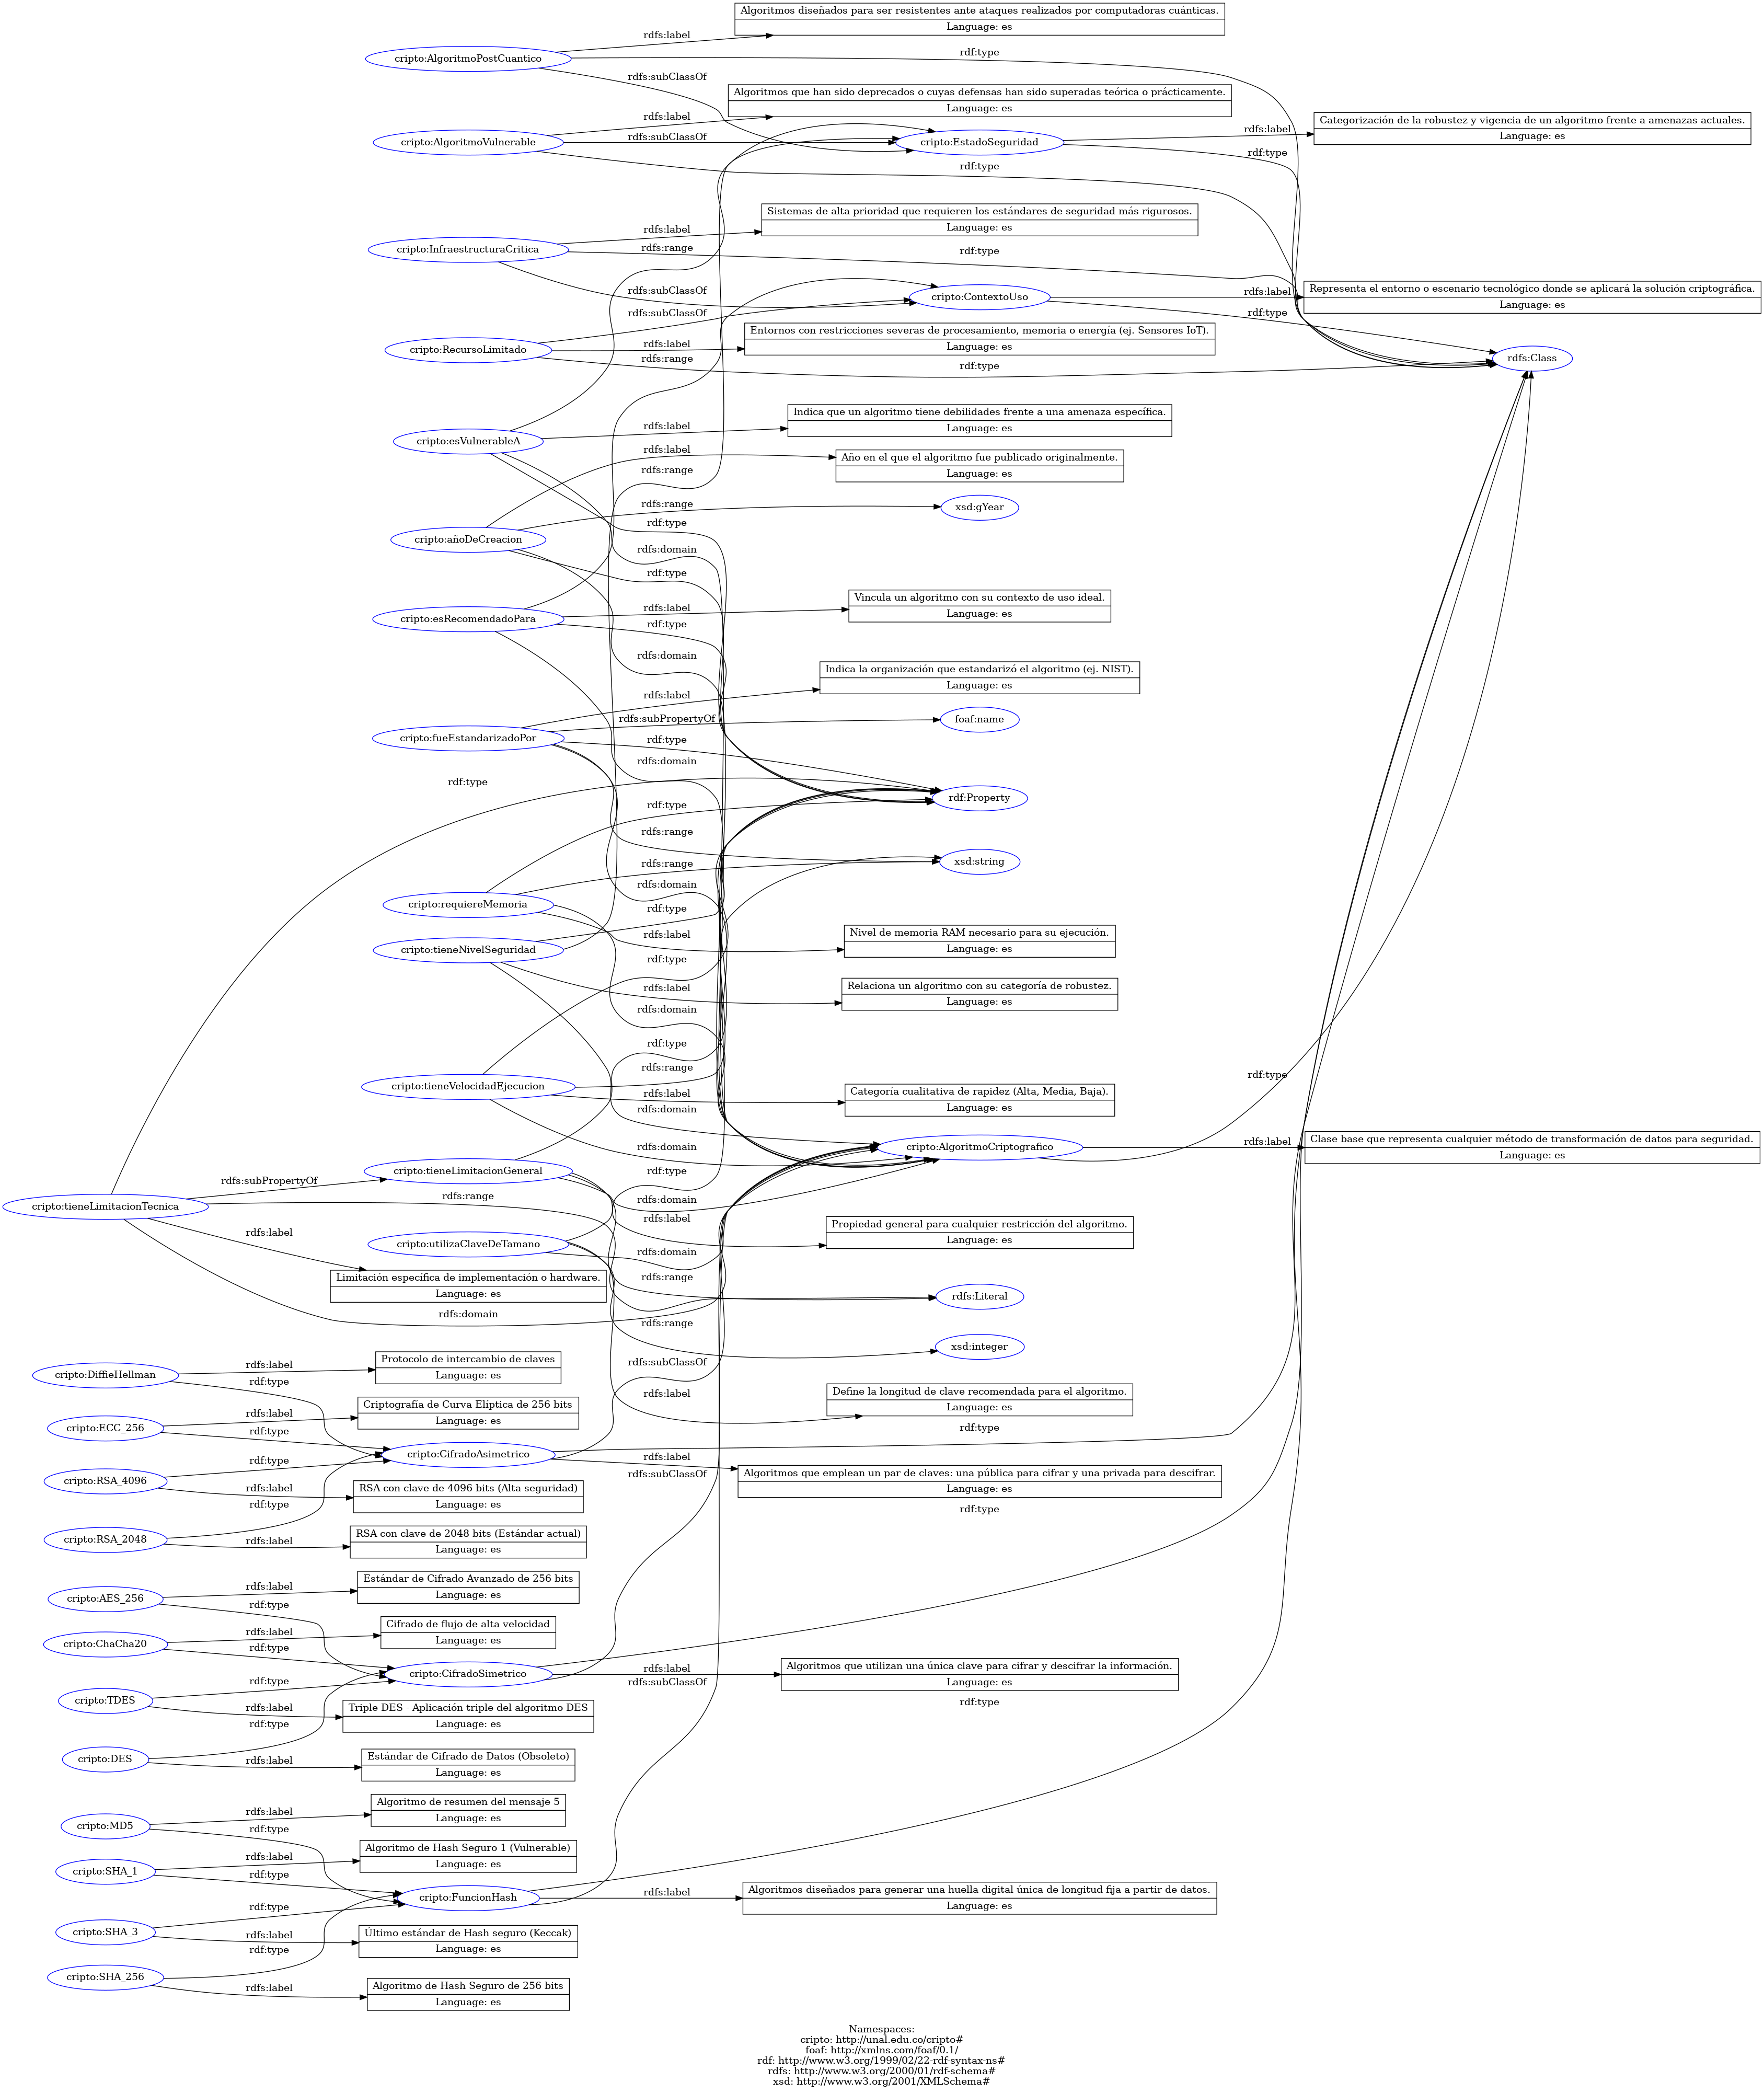

**Inferencia**

In [30]:
grafo_original = Graph()
for s, p, o in g:
    grafo_original.add((s, p, o))

owlrl.DeductiveClosure(owlrl.RDFS_Semantics).expand(g)

nuevos_hechos = g - grafo_original

print("\n--- EVIDENCIA DE INFERENCIAS (Casos del Enunciado) ---")
conteo = 0

for s, p, o in nuevos_hechos:
    # Ignorar tripletas que solo definen el vocabulario base de RDF/RDFS
    # Pero permitir aquellas donde el SUJETO es de nuestro dominio (cripto)
    if "http://unal.edu.co/cripto#" in str(s):

        # Filtro para evitar las reflexivas inútiles (A rdfs:subClassOf A)
        if s == o:
            continue

        # Normalizar para impresión legible
        s_norm = g.namespace_manager.normalizeUri(s)
        p_norm = g.namespace_manager.normalizeUri(p)
        o_norm = g.namespace_manager.normalizeUri(o)

        print(f"Inferencia {conteo+1}: {s_norm} {p_norm} {o_norm}")
        conteo += 1

print(f"\nTotal de inferencias de dominio: {conteo}")

print(g.serialize(format="turtle"))


--- EVIDENCIA DE INFERENCIAS (Casos del Enunciado) ---
Inferencia 1: cripto:Obsoleto rdf:type rdfs:Resource
Inferencia 2: cripto:Dilithium rdf:type cripto:EstadoSeguridad
Inferencia 3: cripto:SHA_256 cripto:tieneLimitacionGeneral <Diseño basado en Merkle-Damgård>
Inferencia 4: cripto:SHA_256 rdf:type cripto:AlgoritmoCriptografico
Inferencia 5: cripto:AutenticacionUsuarios rdf:type rdfs:Resource
Inferencia 6: cripto:AES_256 rdf:type cripto:ContextoUso
Inferencia 7: cripto:Factorizacion_RSA_1024 cripto:tieneLimitacionGeneral <Poder de cómputo actual permite romper estas claves en meses>
Inferencia 8: cripto:Debilidad_RC4 cripto:tieneLimitacionGeneral <Los primeros bytes del keystream no son aleatorios>
Inferencia 9: cripto:RSA_2048 rdf:type cripto:AlgoritmoCriptografico
Inferencia 10: cripto:ECC_ rdf:type cripto:ContextoUso
Inferencia 11: cripto:SphincsPlus foaf:name <NIST (FIPS 205)>
Inferencia 12: cripto:Central_Electrica cripto:tieneLimitacionGeneral <Requiere latencia menor a 10ms p

SISTEMA DIFUSO

In [31]:
!pip install scikit-fuzzy
!pip install numpy
!pip install matplotlib

zsh:1: command not found: pip
zsh:1: command not found: pip
zsh:1: command not found: pip


La robustez requerida es: 87.93%
Nivel de robustez clasificado: Militar


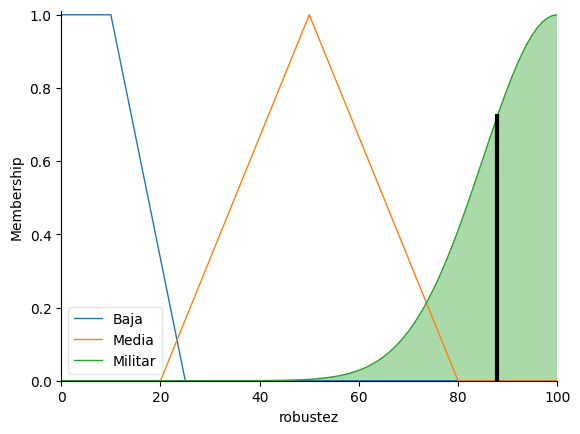

In [32]:
# Importar las bibliotecas necesarias
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl # Módulo que permite implementar el sistema experto difuso funcional (Definir variables lingüísticas, funciones de pertenencia, reglas difusas, Construir el sistema de inferencia)


### Se define los porcentaje y rangos de los unviersos
Porcentaje_recursos = np.arange(0, 101, 1)
Porcetanje_sensibilidad = np.arange(0, 11, 1)
Porentaje_robustez = np.arange(0, 101, 1)


### Se crea los antecedentes y las consecuencias
recursos = ctrl.Antecedent(Porcentaje_recursos, 'recursos')
sensibilidad = ctrl.Antecedent(Porcetanje_sensibilidad, 'sensibilidad')
robustez = ctrl.Consequent(Porentaje_robustez, 'robustez')

robustez.defuzzify_method = 'centroid'

### Se crea las funciones de permanecias para recursos
Bajo = fuzz.trapmf(recursos.universe , [0, 0, 25, 50])
Medio = fuzz.trimf(recursos.universe, [25, 50, 75])
Alto = fuzz.gaussmf(recursos.universe, 100, 25)


#### Se crea las funciones de permanecia para sensibilidad
Publica = fuzz.trapmf(sensibilidad.universe, [0, 0, 2, 4])
Confidencial = fuzz.trimf(sensibilidad.universe, [2, 4, 6])
Secreta = fuzz.gaussmf(sensibilidad.universe, 8, 2.5)


#### Se crea las funciones de permanecia para robustez
Baja = fuzz.trapmf(Porentaje_robustez, [0, 0, 10, 25])
Media = fuzz.trimf(Porentaje_robustez, [20, 50, 80])
Militar = fuzz.gaussmf(Porentaje_robustez, 100, 15)


#### Modificadores

### Para el caso de los Sensibilidad
MUy_secreta = np.power(Secreta, 2)

### Para el caso de los recursos
Ligeramente_bajo = np.sqrt(Bajo)

#### Registro de etiquetas en el sistema de control
recursos['Bajo'] = Bajo
recursos['Medio'] = Medio
recursos['Alto'] = Alto
recursos['Ligeramente_bajo'] = Ligeramente_bajo

sensibilidad['Publica'] = Publica
sensibilidad['Confidencial'] = Confidencial
sensibilidad['Secreta'] = Secreta
sensibilidad['Muy_secreta'] = MUy_secreta

robustez['Baja'] = Baja
robustez['Media'] = Media
robustez['Militar'] = Militar

### Reglas del sistema de logica difusa

Regla1 = ctrl.Rule(recursos['Alto'] & sensibilidad['Publica'], robustez['Baja'])
Regla2 = ctrl.Rule(recursos['Medio'] & sensibilidad['Publica'], robustez['Media'])
Regla3 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Publica'], robustez['Media'])
Regla4 = ctrl.Rule(recursos['Medio'] & sensibilidad['Confidencial'], robustez['Media'])
Regla5 = ctrl.Rule(recursos['Bajo'] & sensibilidad['Confidencial'], robustez['Militar'])
Regla6 = ctrl.Rule(sensibilidad['Secreta'] & ~recursos['Alto'], robustez['Militar'])
Regla7 = ctrl.Rule(recursos['Alto'] & sensibilidad['Secreta'], robustez['Media'])
Regla8 = ctrl.Rule(sensibilidad['Muy_secreta'], robustez['Militar'])
Regla9 = ctrl.Rule(recursos['Ligeramente_bajo'] | sensibilidad['Muy_secreta'], robustez['Militar'])

##### Se crea el sistema de control con las 9 reglas
sistema_control = ctrl.ControlSystem([Regla1, Regla2, Regla3, Regla4, Regla5, Regla6, Regla7, Regla8, Regla9])

#### Se crea la simulación
simulacion = ctrl.ControlSystemSimulation(sistema_control)

#### Se asigna valores de entrada a amnera de ejemplo
simulacion.input['recursos'] = 10
simulacion.input['sensibilidad'] = 9

#### Se realizar la inferencia
simulacion.compute()

#### Resultado
resultado_robustez = simulacion.output['robustez']
print(f"La robustez requerida es: {resultado_robustez:.2f}%")

def clasificar_robustez(valor):

    if valor < 30:
        return "Baja"
    elif valor < 70:
        return "Media"
    else:
        return "Militar"

nivel_robustez = clasificar_robustez(resultado_robustez)

print("Nivel de robustez clasificado:", nivel_robustez)

robustez.view(sim=simulacion)

Sistema Experto

In [33]:
!pip install experta

zsh:1: command not found: pip


In [34]:
!pip install rdflib

zsh:1: command not found: pip


In [35]:
## parcheo
import sys
if sys.version_info >= (3,9):
  import collections
  import collections.abc
  collections.Mapping = collections.abc.Mapping

In [36]:
from experta import *
from rdflib import Graph, Namespace, RDF

### Se realiza la estructura de las 5 clases de hechos


class Algoritmo(Fact):
    nombre = Field(str)
    utilizaClaveTamano = Field(int)
    fueEstandarizadaPor = Field(str)
    tieneVelocidadEjecucion = Field(str)
    requiereMemoria = Field(str)
    añoCreacion = Field(int)


class ContextoUso(Fact):
    algoritmo = Field(str)
    esRecomendadoPara = Field(str)


class Estado_seguridad(Fact):
    algoritmo = Field(str)
    esVulnerableA = Field(str)
    nivel = Field(str)


class Nivel_robustez(Fact):
    algoritmo = Field(str)
    robustez = Field(str)


class Decision_final(Fact):
    algoritmo = Field(str)
    decision = Field(str)

### Definición del Traductor

CRYPTO = Namespace("http://unal.edu.co/cripto#")
NS = CRYPTO


def cargar_ontologia(engine):

    g = Graph()
    g.parse("cripto_ontologia.ttl", format="turtle")

    print("Triples cargados:", len(g))


### Motor de inferencia

class Motorseguridad(KnowledgeEngine):
    #### PRimer grupo de reglas: Recomednación de algoritmos
  ## Regla 1 Robustez maxima
    @Rule(
        Algoritmo(nombre=MATCH.nombre),
        Estado_seguridad(algoritmo=MATCH.nombre, nivel="AltaSeguridad"),
        Nivel_robustez(algoritmo=MATCH.nombre, robustez="Militar"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=10
    )
    def recomendar_algoritmo(self, nombre):
        print(f"{nombre} Altamente recomendado")
        self.declare(Decision_final(algoritmo=nombre, decision="AltamenteRecomendado"))

     ### Regla 2 Robustez media
    @Rule(
        Algoritmo(nombre=MATCH.nombre),
        Estado_seguridad(algoritmo=MATCH.nombre, nivel="AltaSeguridad"),
        Nivel_robustez(algoritmo=MATCH.nombre, robustez="Media"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=8
    )
    def robustez_media(self, nombre):
        print(f"{nombre} Seguridad alta pero robustez media")
        self.declare(Decision_final(algoritmo=nombre, decision="Recomendado"))

    ### Regla 3 seguridad media Robustez alta
    @Rule(
        Algoritmo(nombre=MATCH.nombre),
        Estado_seguridad(algoritmo=MATCH.nombre, nivel="SeguridadMedia"),
        Nivel_robustez(algoritmo=MATCH.nombre, robustez="Militar"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=7
    )
    def seguridad_media(self, nombre):
        print(f"{nombre} Seguridad media con robustez alta")
        self.declare(Decision_final(algoritmo=nombre, decision="Recomendado"))

    ### Regla 4 seguridad media y robustez media
    @Rule(
        Algoritmo(nombre=MATCH.nombre),
        Estado_seguridad(algoritmo=MATCH.nombre, nivel="SeguridadMedia"),
        Nivel_robustez(algoritmo=MATCH.nombre, robustez="Media"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=6
    )
    def seguridad_media_media(self, nombre):
        print(f"{nombre} Uso moderado")
        self.declare(Decision_final(algoritmo=nombre, decision="UsoLimitado"))

     #### Regla 5: seguridad baja
    @Rule(
        Estado_seguridad(algoritmo=MATCH.nombre, nivel="BajaSeguridad"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=9
    )
    def algoritmo_inseguro(self, nombre):
        print(f"{nombre} Algoritmo inseguro")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

  ### Grupo 2 : reglas de retriccion de contexto
  ### Regla 6
    @Rule(
        ContextoUso(algoritmo=MATCH.nombre, esRecomendadoPara="InfraestructuraCritica"),
        Estado_seguridad(algoritmo=MATCH.nombre, nivel=MATCH.nivel),
        TEST(lambda nivel: nivel != "AltaSeguridad"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=8
    )
    def contexto_critico(self, nombre):
        print(f"{nombre}  No cumple seguridad para infraestructura crítica")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

    ###Regla 7 dispositivos con recursos limitados
    @Rule(
        Algoritmo(nombre=MATCH.nombre, requiereMemoria="Alta"),
        ContextoUso(algoritmo=MATCH.nombre, esRecomendadoPara="RecursoLimitado"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=7
    )
    def memoria_excesiva(self, nombre):
        print(f"{nombre}  Demasiada memoria para IoT")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

   ###Regla 8 velocidad insuficiente
    @Rule(
        Algoritmo(nombre=MATCH.nombre, tieneVelocidadEjecucion="Baja"),
        ContextoUso(algoritmo=MATCH.nombre, esRecomendadoPara="RecursoLimitado"),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=6
    )
    def algoritmo_lento(self, nombre):
        print(f"{nombre}  Demasiado lento")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

    ##Regla 9 claves demasidos pequeñas
    @Rule(
        Algoritmo(nombre=MATCH.nombre, utilizaClaveTamano=MATCH.clave),
        TEST(lambda clave: clave < 128),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=9
    )
    def clave_pequena(self, nombre):
        print(f"{nombre} Clave demasiado pequeña")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

    ###Regla 10 Algoritmo vulnerable
    @Rule(
        Estado_seguridad(algoritmo=MATCH.nombre, esVulnerableA=P(lambda x: x != "Ninguna")),
        NOT(Decision_final(algoritmo=MATCH.nombre)),
        salience=10
    )
    def algoritmo_vulnerable(self, nombre):
        print(f"{nombre} Vulnerabilidad detectada")
        self.declare(Decision_final(algoritmo=nombre, decision="NoRecomendado"))

    ### Grupo 3 Reglas de decisión final basadas en la robustez
    ###Regla 11: Robuestez muy alta
    @Rule(
    Nivel_robustez(algoritmo=MATCH.nombre_algo, robustez="Militar"),
    Estado_seguridad(algoritmo=MATCH.nombre_algo, nivel="AltaSeguridad"),
    NOT(Decision_final(algoritmo=MATCH.nombre_algo)),
    salience=6
    )
    def algoritmo_altamente_recomendado(self, nombre_algo):
      print(f"Altamente Recomendado: {nombre_algo}")
      self.declare(Decision_final(algoritmo=nombre_algo, decision="AltamenteRecomendado"))

    ### Regla 12: Robustez alta
    @Rule(
    Nivel_robustez(algoritmo=MATCH.nombre_algo, robustez="Alta"),
    NOT(Decision_final(algoritmo=MATCH.nombre_algo)),
    salience=5
   )
    def algoritmo_recomendado(self, nombre_algo):
      print(f"Recomendado: {nombre_algo}")
      self.declare(Decision_final(algoritmo=nombre_algo, decision="Recomendado"))

    #### Regla 13: Robustez media
    @Rule(
    Nivel_robustez(algoritmo=MATCH.nombre_algo, robustez="Media"),
    NOT(Decision_final(algoritmo=MATCH.nombre_algo)),
    salience=4
    )
    def algoritmo_uso_limitado(self, nombre_algo):
      print(f"Uso limitado: {nombre_algo}")
      self.declare(Decision_final(algoritmo=nombre_algo, decision="UsoLimitado"))

    ###Regla 14: Robustez baja
    @Rule(
    Nivel_robustez(algoritmo=MATCH.nombre_algo, robustez="Baja"),
    NOT(Decision_final(algoritmo=MATCH.nombre_algo)),
    salience=3
    )
    def algoritmo_no_recomendado(self, nombre_algo):
      print(f"No recomendado: {nombre_algo}")
      self.declare(Decision_final(algoritmo=nombre_algo, decision="NoRecomendado"))

    ### Regla 15: Regla final de respaldo
    @Rule(
        Decision_final(algoritmo=MATCH.nombre, decision=MATCH.d),
        salience=-1
    )
    def mostrar_decision(self, nombre, d):
        print(f"Decisión final: {nombre}: {d}")


### Ejecución del sistema

if __name__ == "__main__":
    def limpiar_uri(valor):
        if valor is None:
            return None
        return str(valor).split("#")[-1]

    engine = Motorseguridad()
    engine.reset()
    cargar_ontologia(engine)

    print("\nEjecutando motor de inferencia...\n")

    engine.declare(
    Algoritmo(
        nombre="AES_Test",
        utilizaClaveTamano=256,
        fueEstandarizadaPor="NIST",
        tieneVelocidadEjecucion="Alta",
        requiereMemoria="Media",
        añoCreacion=2001
    )
)

engine.declare(
    Estado_seguridad(
        algoritmo="AES_Test",
        nivel="AltaSeguridad"
    )
)

engine.declare(
    Nivel_robustez(
        algoritmo="AES_Test",
        robustez="Militar"
    )
)

print("\nHechos en la base:")
for fid, fact in engine.facts.items():
    print(fid, fact)

for sujeto, tipo in g.subject_objects(RDF.type):
      tipo_str = str(tipo)

      if ("Cifrado" in tipo_str or
        "Hash" in tipo_str or
        "PostCuantico" in tipo_str):

        nombre_id = str(sujeto).split("#")[-1]

        clave = int(limpiar_uri(g.value(sujeto, NS.utilizaClaveDeTamano) or 0))#
        estandar = str(limpiar_uri(g.value(sujeto, NS.fueEstandarizadoPor) or "N/A"))
        velocidad = str(limpiar_uri(g.value(sujeto, NS.tieneVelocidadEjecucion) or "Media"))
        memoria = str(limpiar_uri(g.value(sujeto, NS.requiereMemoria) or "Media"))
        año = int(limpiar_uri(g.value(sujeto, NS.añoDeCreacion) or 0))

        nivel_seguridad = str(limpiar_uri(g.value(sujeto, NS.tieneNivelSeguridad) or "Desconocido"))
        vulnerabilidad = str(limpiar_uri(g.value(sujeto, NS.esVulnerableA) or "Ninguna"))

        contexto = str(limpiar_uri(g.value(sujeto, NS.esRecomendadoPara) or "General"))

        engine.declare(
            Algoritmo(
                nombre=nombre_id,
                utilizaClaveTamano=clave,
                fueEstandarizadaPor=estandar,
                tieneVelocidadEjecucion=velocidad,
                requiereMemoria=memoria,
                añoCreacion=año
            )
        )

        engine.declare(
            Estado_seguridad(
                algoritmo=nombre_id,
                esVulnerableA=vulnerabilidad,
                nivel=nivel_seguridad
            )
        )

        engine.declare(
            ContextoUso(
                algoritmo=nombre_id,
                esRecomendadoPara=contexto
            )
        )

        print("Hechos creados para:", nombre_id)
print("\nTotal de hechos:", len(engine.facts))

from experta import InitialFact

print("\nHECHOS BASE DECLARADOS, ANTES DE INFERENCIA:\n")

contador = 0

for fid, fact in engine.facts.items():
    if isinstance(fact, InitialFact):
        continue

    contador += 1

    print(f"Hecho base #{contador}")
    print(f"ID interno: {fid}")
    print(f"Tipo: {type(fact).__name__}")

    print("Campos:")
    for campo, valor in fact.items():
        print(f"  {campo}: {valor}")

    print("-" * 50)

print(f"\nTotal de hechos base declarados: {contador}")

engine.run()

Triples cargados: 380

Ejecutando motor de inferencia...


Hechos en la base:
0 <f-0>
1 <f-1>
2 <f-2>
3 <f-3>
Hechos creados para: AES_256
Hechos creados para: DES
Hechos creados para: TDES
Hechos creados para: ChaCha20
Hechos creados para: RSA_2048
Hechos creados para: RSA_4096
Hechos creados para: ECC_256
Hechos creados para: DiffieHellman
Hechos creados para: SHA_256
Hechos creados para: SHA_1
Hechos creados para: MD5
Hechos creados para: SHA_3
Hechos creados para: Kyber
Hechos creados para: Dilithium
Hechos creados para: SphincsPlus
Hechos creados para: Falcon

Total de hechos: 52

HECHOS BASE DECLARADOS, ANTES DE INFERENCIA:

Hecho base #1
ID interno: 1
Tipo: Algoritmo
Campos:
  nombre: AES_Test
  utilizaClaveTamano: 256
  fueEstandarizadaPor: NIST
  tieneVelocidadEjecucion: Alta
  requiereMemoria: Media
  añoCreacion: 2001
  __factid__: 1
--------------------------------------------------
Hecho base #2
ID interno: 2
Tipo: Estado_seguridad
Campos:
  algoritmo: AES_Test
  nivel: Al